In [22]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

#### Importing Dataset

In [23]:
data_dir = '../data/'

df = pd.read_csv(os.path.join(data_dir, 'combined.csv'))

df.head()

,Sample_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000283907,ENSG00000283913,ENSG00000284032,ENSG00000284373,ENSG00000284387,ENSG00000284395,ENSG00000284505,ENSG00000284552,Disease,characteristics_ch1_bmi
0,GSM1501013,8.002176,0.175238,4.949994,3.285351,0.959516,0.672894,59.325067,4.168056,8.104327,...,3.031789,0.903138,1.222211,0.132392,0.491394,-0.079424,-0.255411,3.071849,normal control,27.1
1,GSM1501014,23.292853,-0.031148,5.657237,2.786927,1.203578,0.358625,46.002714,4.889903,7.588060,...,1.819534,-0.021741,0.487849,-0.066907,0.195198,0.178077,-0.190626,1.399320,healthy obese,30.5
2,GSM1501015,10.557890,0.097413,7.680354,2.795125,0.789783,0.733455,43.835288,5.133417,9.559194,...,1.914932,0.424076,0.423539,-0.155705,0.086307,0.230390,-0.489850,1.632879,normal control,25.3
3,GSM1501016,10.272135,0.066298,8.835539,3.166677,0.941032,0.755181,51.390227,4.168056,10.980774,...,1.313128,0.501803,0.357365,-0.321937,0.232894,-0.066718,-0.233382,2.117271,normal control,25.8
4,GSM1501017,8.290414,-0.039647,5.792685,2.203175,0.846344,0.612263,55.423440,3.657327,10.710821,...,4.507792,0.120017,0.452607,-0.263615,0.443599,0.291308,-0.474034,3.032463,normal control,23.5


In [24]:
df = df.drop(columns='characteristics_ch1_bmi', errors='ignore')

df = df[(df['Disease'] == 'nash') | (df['Disease'] == 'nafld') | (df['Disease'] == 'normal control')]

df['Disease'].count()

np.int64(84)

In [25]:
combination_map = {
    'nash': 'Fatty Liver Disease',
    'nafld': 'Fatty Liver Disease',
    'normal control': 'Healthy Control',
}

df['Disease'] = df['Disease'].map(combination_map)


In [26]:
df = df[['ENSG00000182771',
'ENSG00000164309',
'ENSG00000075391',
'ENSG00000132329',
'ENSG00000170006',
'ENSG00000171132',
'ENSG00000135318',
'ENSG00000175336',
'ENSG00000183049',
'ENSG00000198189',
'Disease']]
       

df.head()

,ENSG00000182771,ENSG00000164309,ENSG00000075391,ENSG00000132329,ENSG00000170006,ENSG00000171132,ENSG00000135318,ENSG00000175336,ENSG00000183049,ENSG00000198189,Disease
0,0.251788,1.556209,1.644653,0.758614,1.088966,1.516069,6.380487,26.716450,1.857922,29.873380,Healthy Control
2,0.735002,1.219835,1.161706,0.844393,3.878616,1.055961,7.348991,32.567208,2.309189,34.716435,Healthy Control
3,0.159867,1.317961,1.460158,0.670711,1.159176,1.320756,6.116717,27.574305,2.047091,37.204955,Healthy Control
4,0.054296,0.595724,0.770201,1.510349,1.097572,0.955619,5.265172,35.266371,1.725493,33.494555,Healthy Control
6,0.332105,0.382648,1.240630,0.682496,3.362448,3.369482,6.020625,20.663791,3.358313,18.390883,Fatty Liver Disease


#### Encoding categorical data

In [27]:
le = LabelEncoder()

y = le.fit_transform(df['Disease'])

# X = df.drop(columns = ['Sample_ID', 'Disease'])
X = df.drop(columns = ['Disease'])

X.head()

,ENSG00000182771,ENSG00000164309,ENSG00000075391,ENSG00000132329,ENSG00000170006,ENSG00000171132,ENSG00000135318,ENSG00000175336,ENSG00000183049,ENSG00000198189
0,0.251788,1.556209,1.644653,0.758614,1.088966,1.516069,6.380487,26.716450,1.857922,29.873380
2,0.735002,1.219835,1.161706,0.844393,3.878616,1.055961,7.348991,32.567208,2.309189,34.716435
3,0.159867,1.317961,1.460158,0.670711,1.159176,1.320756,6.116717,27.574305,2.047091,37.204955
4,0.054296,0.595724,0.770201,1.510349,1.097572,0.955619,5.265172,35.266371,1.725493,33.494555
6,0.332105,0.382648,1.240630,0.682496,3.362448,3.369482,6.020625,20.663791,3.358313,18.390883


#### Train, Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(X_train.shape)
print(X_test.shape)

(67, 10)
(17, 10)


## Support Vector Machine

#### Defining Pipline

In [29]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', SVC(class_weight='balanced')) 
]
pipeline = ImbPipeline(pipeline_steps)
print("\nDefined Pipeline:")
print(pipeline)


Defined Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(class_weight='balanced'))])


#### Training, Optimising and Results


Starting RandomizedSearchCV on Pipeline...
RandomizedSearchCV on Pipeline complete.

Best hyperparameters found for the pipeline:
{'classifier__kernel': 'linear', 'classifier__C': np.float64(0.03162277660168379)}

Best cross-validation score:
0.8803968253968254

Best Pipeline Model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 SVC(C=np.float64(0.03162277660168379), class_weight='balanced',
                     kernel='linear'))])

--- Evaluation of Best Tuned Pipeline on Test Set ---
Accuracy: 1.0

Classification Report:
                     precision  recall  f1-score  support
Fatty Liver Disease        1.0     1.0       1.0      9.0
Healthy Control            1.0     1.0       1.0      8.0
macro avg                  1.0     1.0       1.0     17.0
weighted avg               1.0     1.0       1.0     17.0

Confusion Matrix:


/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=200. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


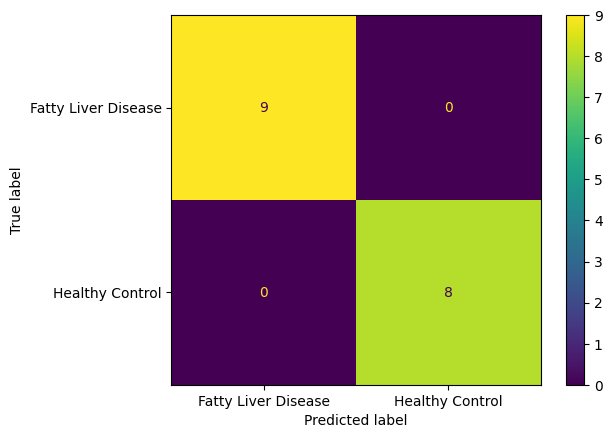

In [30]:
param_dist = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': np.logspace(-3, 3, 5),
    },
    
    # {
    #     'classifier__kernel': ['rbf'],
    #     'classifier__C': np.logspace(-3, 3, 5),
    #     'classifier__gamma': np.logspace(-3, 3, 5),
    # },
]

random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline,                
    param_distributions=param_dist,  
    n_iter=200,                        
    cv=10,                            
    scoring='f1_weighted',             
    verbose=0,                   
    n_jobs=-1                          
)

print("\nStarting RandomizedSearchCV on Pipeline...")
random_search_pipeline.fit(X_train, y_train)
print("RandomizedSearchCV on Pipeline complete.")

print("\nBest hyperparameters found for the pipeline:")
print(random_search_pipeline.best_params_)

print("\nBest cross-validation score:")
print(random_search_pipeline.best_score_)

best_pipeline_model = random_search_pipeline.best_estimator_
print("\nBest Pipeline Model:")
print(best_pipeline_model)

y_pred_tuned = best_pipeline_model.predict(X_test)

print("\n--- Evaluation of Best Tuned Pipeline on Test Set ---")
svm_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy: {svm_accuracy}")
print("\nClassification Report:")

svm_classfication_report = classification_report(y_test, y_pred_tuned, target_names=le.classes_, output_dict=True)
svm_classfication_report = pd.DataFrame(svm_classfication_report).transpose().drop('accuracy')
print(svm_classfication_report)

best_scaler = best_pipeline_model.named_steps['scaler']
best_classifier = best_pipeline_model.named_steps['classifier']

svm_conf_matrix = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix,
                              display_labels=le.classes_)
disp.plot()
plt.show()

#### Feature Importance


--- Top 20 Most Relevant Features ---
           feature  importance
0  ENSG00000182771    0.362851
3  ENSG00000132329    0.251154
2  ENSG00000075391    0.213984
6  ENSG00000135318    0.207931
4  ENSG00000170006    0.200452
7  ENSG00000175336    0.197009
1  ENSG00000164309    0.163341
8  ENSG00000183049    0.137719
9  ENSG00000198189    0.084964
5  ENSG00000171132    0.027737


<Axes: xlabel='importance', ylabel='feature'>

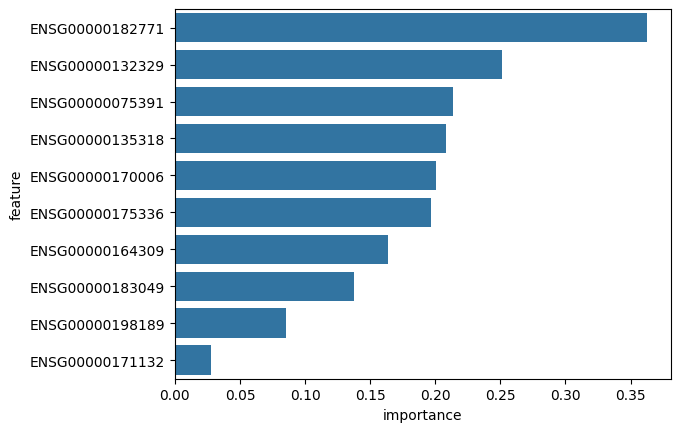

In [31]:
importances = np.abs(best_classifier.coef_[0])

feature_names = X_train.columns.tolist()

svm_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

svm_feature_importance_df = svm_feature_importance_df.sort_values(by='importance', ascending=False)

print("\n--- Top 20 Most Relevant Features ---")
print(svm_feature_importance_df.head(20))

sns.barplot(x='importance', y='feature', data=svm_feature_importance_df.head(20))

## Gradient Boosted Decision Tree

#### Defining Pipline

In [32]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        device='cuda', 
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=1.65))
]
pipeline = ImbPipeline(pipeline_steps)
print("\nDefined Pipeline:")
print(pipeline)


Defined Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=n

#### Training, Optimising and Results


Starting RandomizedSearchCV on Pipeline...


/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:53:43] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:53:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expression-Analysis/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:53:43] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/jaydn/Documents/GitHub/Human-Liver-RNA-Seq-Gene-Expressio

RandomizedSearchCV on Pipeline complete.

Best hyperparameters found for the pipeline:
{'classifier__class_weight': 'balanced', 'classifier__colsample_bytree': np.float64(0.6764917300286076), 'classifier__eval_metric': 'mlogloss', 'classifier__gamma': np.float64(1.2190109726836457e-09), 'classifier__learning_rate': np.float64(0.038030313895780266), 'classifier__max_depth': 2, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 106, 'classifier__reg_alpha': np.float64(0.00028635890686062355), 'classifier__reg_lambda': np.float64(8.03766657180527e-07), 'classifier__subsample': np.float64(0.8513065048553526), 'classifier__use_label_encoder': False}

Best cross-validation score:
0.9095238095238095

Best Pipeline Model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               class_weight='balanced', colsample_bylevel=None,
                             

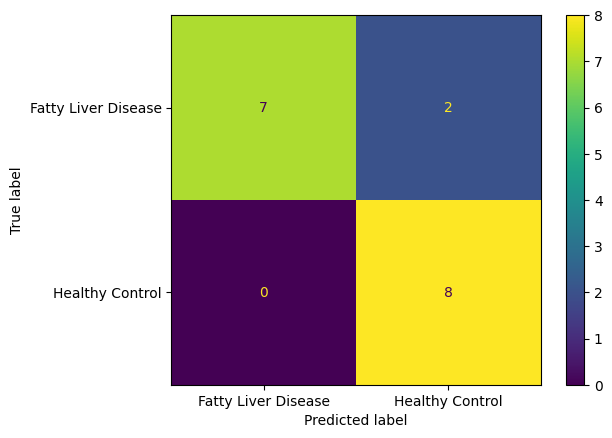

In [33]:
# good parameters
# {'classifier__class_weight': None, 'classifier__colsample_bytree': np.float64(0.8755909403702945), 'classifier__eval_metric': 'mlogloss', 'classifier__gamma': np.float64(0.00342149482772333), 'classifier__learning_rate': np.float64(0.009859525935595078), 'classifier__max_depth': 2, 'classifier__min_child_weight': 4, 'classifier__n_estimators': 392, 'classifier__reg_alpha': np.float64(1.4032073545864337e-05), 'classifier__reg_lambda': np.float64(0.0006988032796254695), 'classifier__subsample': np.float64(0.6430522399631521), 'classifier__use_label_encoder': False}


param_dist = {
    'classifier__n_estimators': randint(100, 500),
    'classifier__learning_rate': loguniform(0.001, 0.1),
    'classifier__max_depth': randint(1, 4),
    
    'classifier__colsample_bytree': uniform(0.5, 0.5), 
    
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__gamma': loguniform(1e-9, 1e-1),
    'classifier__min_child_weight': randint(1, 5),
    'classifier__reg_alpha': loguniform(1e-9, 1e-1),
    'classifier__reg_lambda': loguniform(1e-9, 1e-1),

    'classifier__eval_metric': ['mlogloss'],
    'classifier__use_label_encoder': [False],
    'classifier__class_weight': [None, 'balanced']
}

random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline,                
    param_distributions=param_dist,  
    n_iter=20,                   
    cv=5,                         
    scoring='f1_weighted',         
    verbose=0,                   
    n_jobs=8                          
)

print("\nStarting RandomizedSearchCV on Pipeline...")
random_search_pipeline.fit(X_train, y_train)
print("RandomizedSearchCV on Pipeline complete.")

print("\nBest hyperparameters found for the pipeline:")
print(random_search_pipeline.best_params_)

print("\nBest cross-validation score:")
print(random_search_pipeline.best_score_)

best_pipeline_model = random_search_pipeline.best_estimator_
print("\nBest Pipeline Model:")
print(best_pipeline_model)

y_pred_tuned = best_pipeline_model.predict(X_test)

print("\n--- Evaluation of Best Tuned Pipeline on Test Set ---")
xgb_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy: {xgb_accuracy}")

# print("\nClassification Report:")
xgb_classification_report = classification_report(y_test, y_pred_tuned, target_names=le.classes_, output_dict=True)
xgb_classification_report = pd.DataFrame(xgb_classification_report).transpose().drop('accuracy')
print(xgb_classification_report)

best_scaler = best_pipeline_model.named_steps['scaler']
best_classifier = best_pipeline_model.named_steps['classifier']

xgb_conf_matrix = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_conf_matrix,
                              display_labels=le.classes_)
disp.plot()
plt.show()

#### Feature Importance


--- Top 20 Most Relevant Features ---
           feature  importance
5  ENSG00000171132    0.247450
0  ENSG00000182771    0.166891
3  ENSG00000132329    0.132664
2  ENSG00000075391    0.124487
8  ENSG00000183049    0.100476
9  ENSG00000198189    0.068315
4  ENSG00000170006    0.061023
6  ENSG00000135318    0.059446
7  ENSG00000175336    0.030492
1  ENSG00000164309    0.008754


<Axes: xlabel='importance', ylabel='feature'>

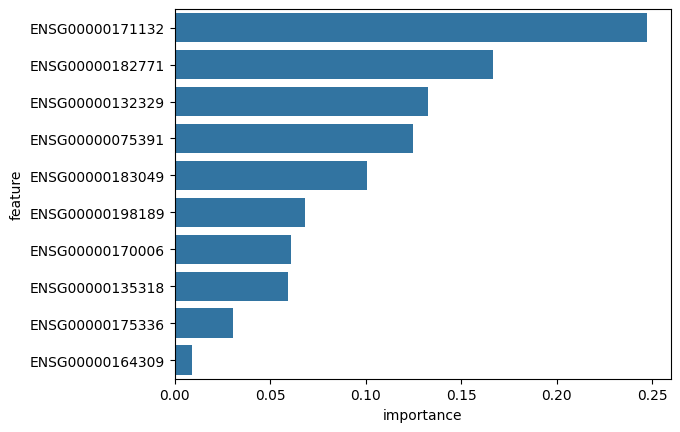

In [34]:
best_classifier = best_pipeline_model.named_steps['classifier']
importances = best_classifier.feature_importances_

feature_names = X_train.columns.tolist()

xgb_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='importance', ascending=False)

print("\n--- Top 20 Most Relevant Features ---")
print(xgb_feature_importance_df.head(20))

sns.barplot(x='importance', y='feature', data=xgb_feature_importance_df.head(20))

## Random Forest

#### Defining Pipline

In [35]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier())
]
pipeline = ImbPipeline(pipeline_steps)
print("\nDefined Pipeline:")
print(pipeline)


Defined Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier())])


#### Training, Optimising and Results


Starting RandomizedSearchCV on Pipeline...
RandomizedSearchCV on Pipeline complete.

Best hyperparameters found for the pipeline:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.1, 'classifier__max_depth': 20, 'classifier__bootstrap': True}

Best cross-validation score:
0.941529059176118

Best Pipeline Model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=20, max_features=0.1,
                                        min_samples_split=5))])

--- Evaluation of Best Tuned Pipeline on Test Set ---
Accuracy: 0.9411764705882353
                     precision    recall  f1-score  support
Fatty Liver Disease   1.000000  0.888889  0.941176      9.0
Healthy Control       0.888889  1.000000  0.941176      8.0
macro avg             0.944444  0.944444  0.941176     17.0
weighted avg          0.947712  0.941176  0.941176     17.0

Con

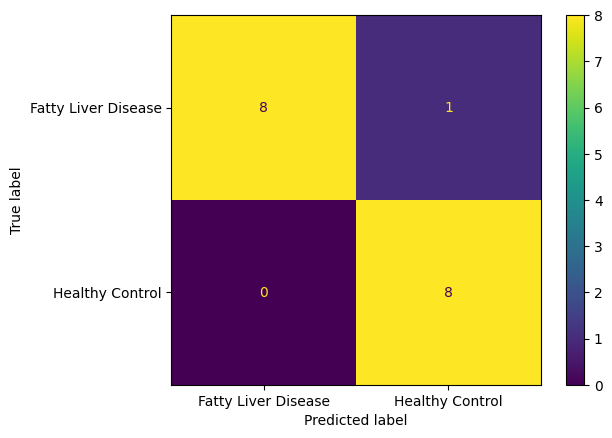

In [36]:
# good parameters:
# {'classifier__n_estimators': 250, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.1, 'classifier__max_depth': None, 'classifier__bootstrap': True}

param_dist = {

    'classifier__n_estimators': [100, 250, 500, 1000],

    'classifier__max_features': ['sqrt', 'log2', 0.05, 0.1], 
    
    'classifier__max_depth': [3, 5, 10, 15, 20, None],

    'classifier__min_samples_split': [2, 5, 10, 20],

    'classifier__min_samples_leaf': [1, 2, 5, 10],

    'classifier__bootstrap': [True] 
}
  
random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist,
    scoring='f1_weighted',  
    n_iter=100, 
    cv=5, 
    verbose=0, 
    random_state=42, 
    n_jobs=-1)

print("\nStarting RandomizedSearchCV on Pipeline...")
random_search_pipeline.fit(X_train, y_train)
print("RandomizedSearchCV on Pipeline complete.")

print("\nBest hyperparameters found for the pipeline:")
print(random_search_pipeline.best_params_)

print("\nBest cross-validation score:")
print(random_search_pipeline.best_score_)

best_pipeline_model = random_search_pipeline.best_estimator_
print("\nBest Pipeline Model:")
print(best_pipeline_model)

y_pred_tuned = best_pipeline_model.predict(X_test)

print("\n--- Evaluation of Best Tuned Pipeline on Test Set ---")
random_forest_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy: {random_forest_accuracy}")
# print("\nClassification Report:")
random_forest_classification_report = classification_report(y_test, y_pred_tuned, target_names=le.classes_, output_dict=True)
random_forest_classification_report = pd.DataFrame(random_forest_classification_report).transpose().drop('accuracy')
print(random_forest_classification_report)

best_scaler = best_pipeline_model.named_steps['scaler']
best_classifier = best_pipeline_model.named_steps['classifier']

random_forest_conf_matrix = confusion_matrix(y_test, y_pred_tuned)
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=random_forest_conf_matrix,
                              display_labels=le.classes_)
disp.plot()
plt.show()

#### Feature Importance


--- Top 20 Most Relevant Features ---
           feature  importance
0  ENSG00000182771    0.156802
5  ENSG00000171132    0.134437
2  ENSG00000075391    0.125126
9  ENSG00000198189    0.110510
3  ENSG00000132329    0.101299
4  ENSG00000170006    0.097566
8  ENSG00000183049    0.094078
7  ENSG00000175336    0.076574
6  ENSG00000135318    0.054017
1  ENSG00000164309    0.049590


<Axes: xlabel='importance', ylabel='feature'>

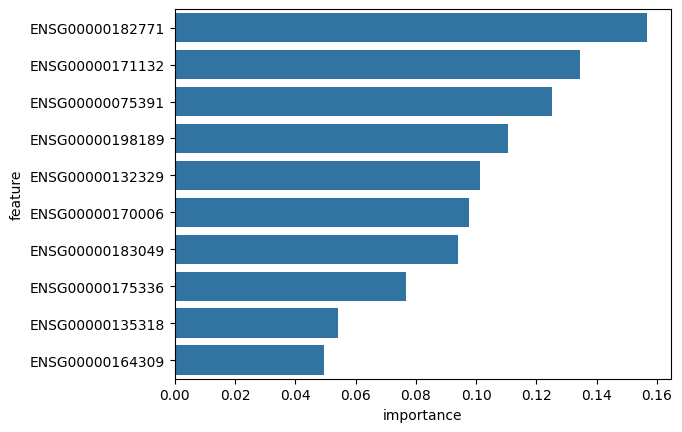

In [37]:
best_classifier = best_pipeline_model.named_steps['classifier']
importances = best_classifier.feature_importances_

feature_names = X_train.columns.tolist()

random_forest_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

random_forest_feature_importance_df = random_forest_feature_importance_df.sort_values(by='importance', ascending=False)

print("\n--- Top 20 Most Relevant Features ---")
print(random_forest_feature_importance_df.head(20))

sns.barplot(x='importance', y='feature', data=random_forest_feature_importance_df.head(20))

## Evaluation

#### Comparison of Accuracy

<BarContainer object of 3 artists>

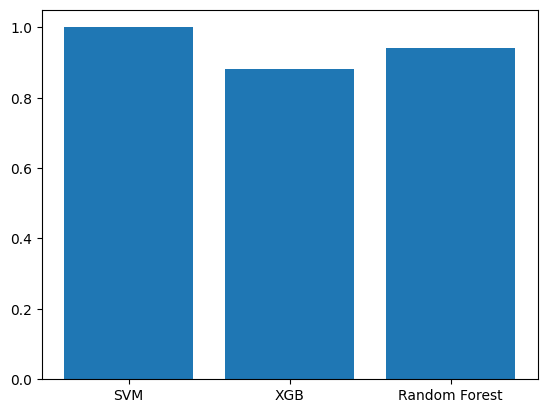

In [38]:
x = ["SVM", "XGB", "Random Forest"]
y = [svm_accuracy, xgb_accuracy, random_forest_accuracy]

plt.bar(x,y)


#### Comparison of Confusion Matrices

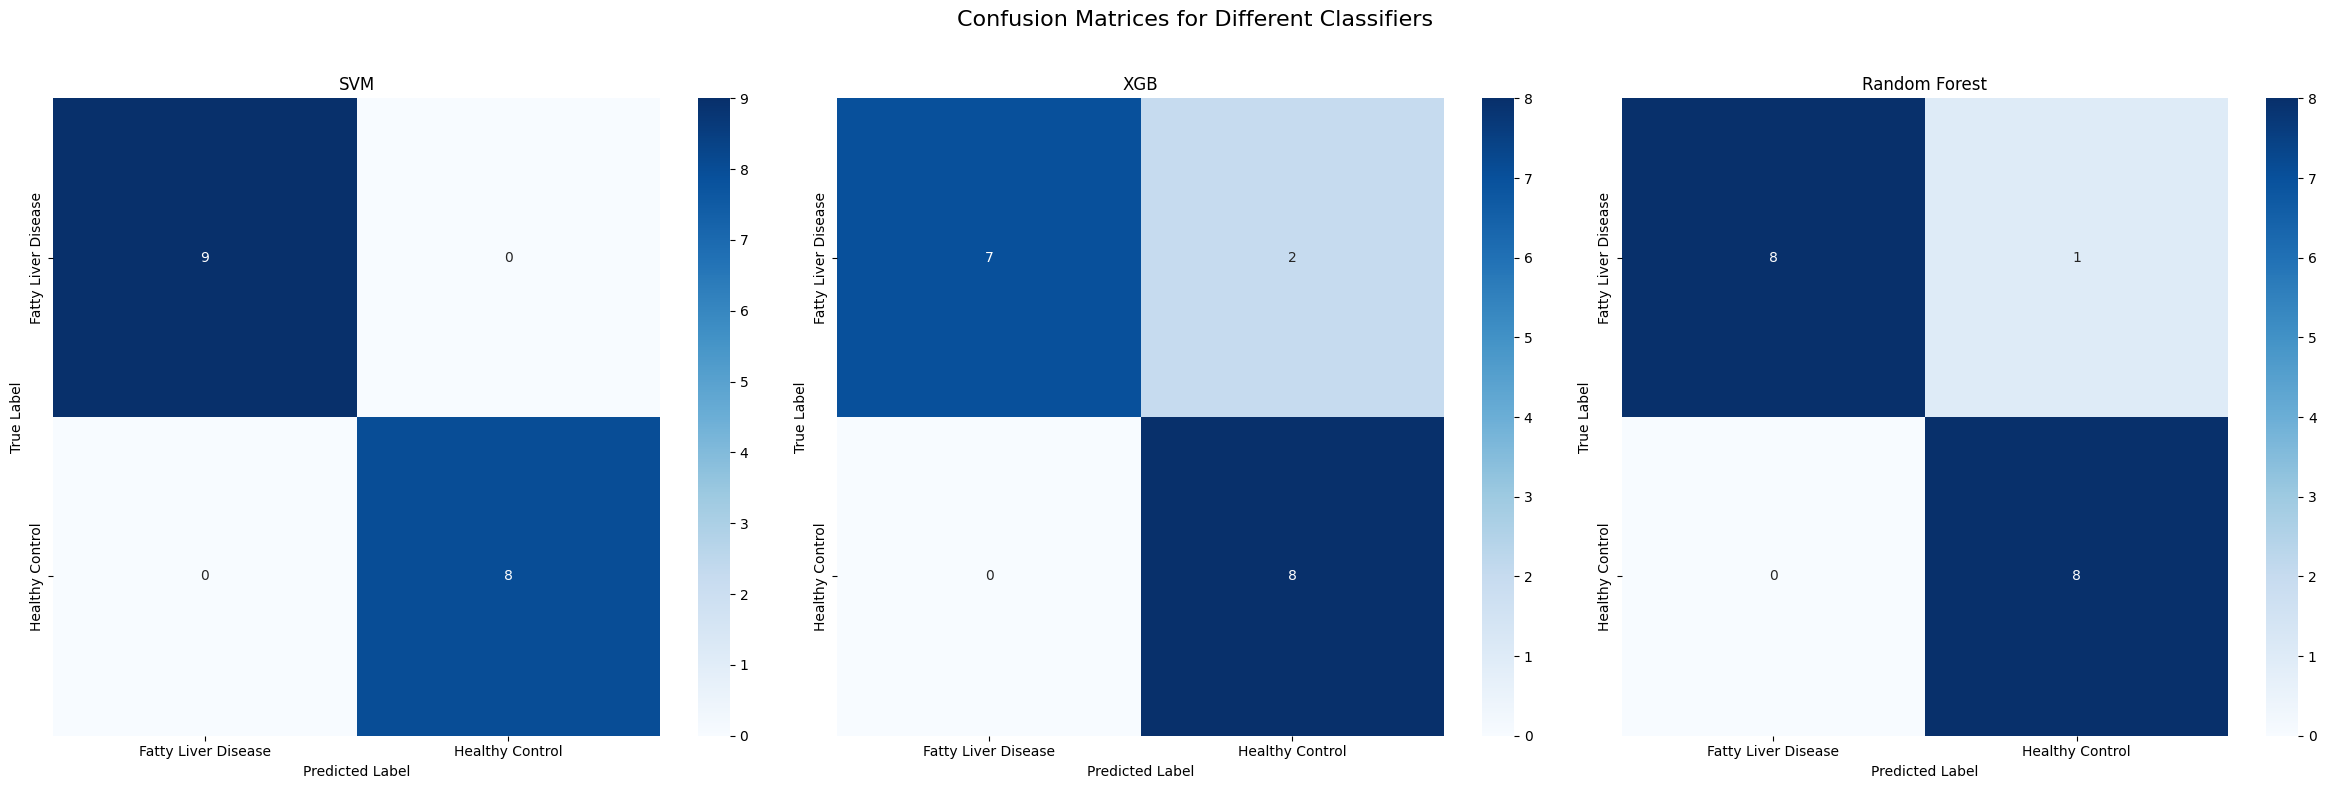

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

matrices = [svm_conf_matrix, xgb_conf_matrix, random_forest_conf_matrix]
titles = ['SVM', 'XGB', 'Random Forest']

for i, (matrix, title) in enumerate(zip(matrices, titles)):
    sns.heatmap(matrix, 
                ax=axes[i], 
                annot=True, 
                fmt="d", 
                cmap="Blues", 
                xticklabels=le.classes_, 
                yticklabels=le.classes_)
    axes[i].set_title(title)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

fig.suptitle('Confusion Matrices for Different Classifiers', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

#### Comparision of Important Features

In [40]:
frames = [svm_feature_importance_df.head(20), xgb_feature_importance_df.head(20), random_forest_feature_importance_df.head(20)]

combined_frames = pd.concat(frames)

combined_frames = combined_frames.drop(columns='importance')

values_counts = combined_frames.value_counts()

feature_counts_df = values_counts.reset_index()
feature_counts_df.columns = ['feature', 'model_count']

print("--- Features by Consensus Importance ---")
print("---------------------------------------")
print("Feature        | Appears in (Models) |")
print("---------------------------------------")
for _, row in feature_counts_df.head(20).iterrows():
    print(f"{row['feature']:<14} | {row['model_count']:<19} |")
print("---------------------------------------")

--- Features by Consensus Importance ---
---------------------------------------
Feature        | Appears in (Models) |
---------------------------------------
ENSG00000075391 | 3                   |
ENSG00000132329 | 3                   |
ENSG00000135318 | 3                   |
ENSG00000164309 | 3                   |
ENSG00000170006 | 3                   |
ENSG00000171132 | 3                   |
ENSG00000175336 | 3                   |
ENSG00000182771 | 3                   |
ENSG00000183049 | 3                   |
ENSG00000198189 | 3                   |
---------------------------------------


ENSG00000182771 | 3                   |
ENSG00000164309 | 3                   |
ENSG00000075391 | 2                   |
ENSG00000132329 | 2                   |
ENSG00000170006 | 2                   |
ENSG00000171132 | 2                   |
ENSG00000135318 | 2                   |
ENSG00000175336 | 2                   |
ENSG00000183049 | 2                   |
ENSG00000198189 | 2                   |

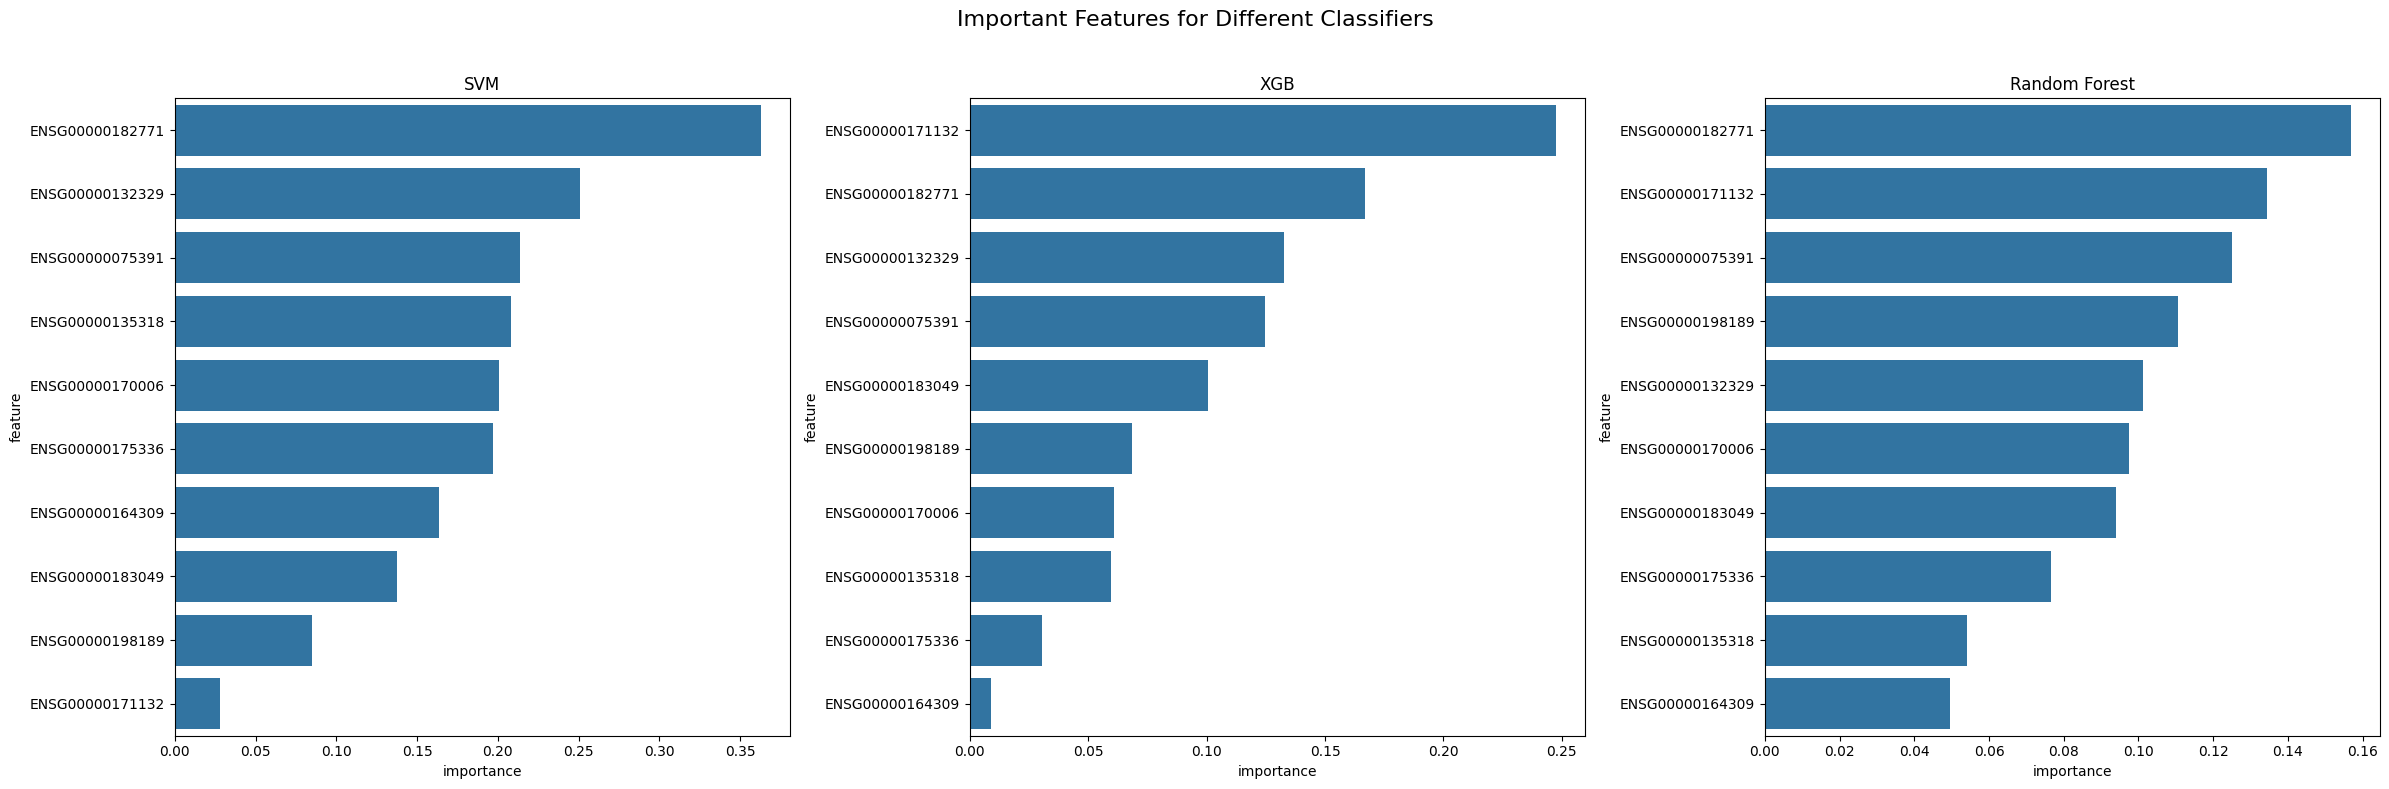

In [41]:

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

matrices = [svm_feature_importance_df, xgb_feature_importance_df, random_forest_feature_importance_df]
titles = ['SVM', 'XGB', 'Random Forest']

for i, (matrix, title) in enumerate(zip(matrices, titles)):
    sns.barplot(x='importance', y='feature', data=matrix.head(20), ax=axes[i],)
    axes[i].set_title(title)

fig.suptitle('Important Features for Different Classifiers', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

#### Comparision of Classification Reports

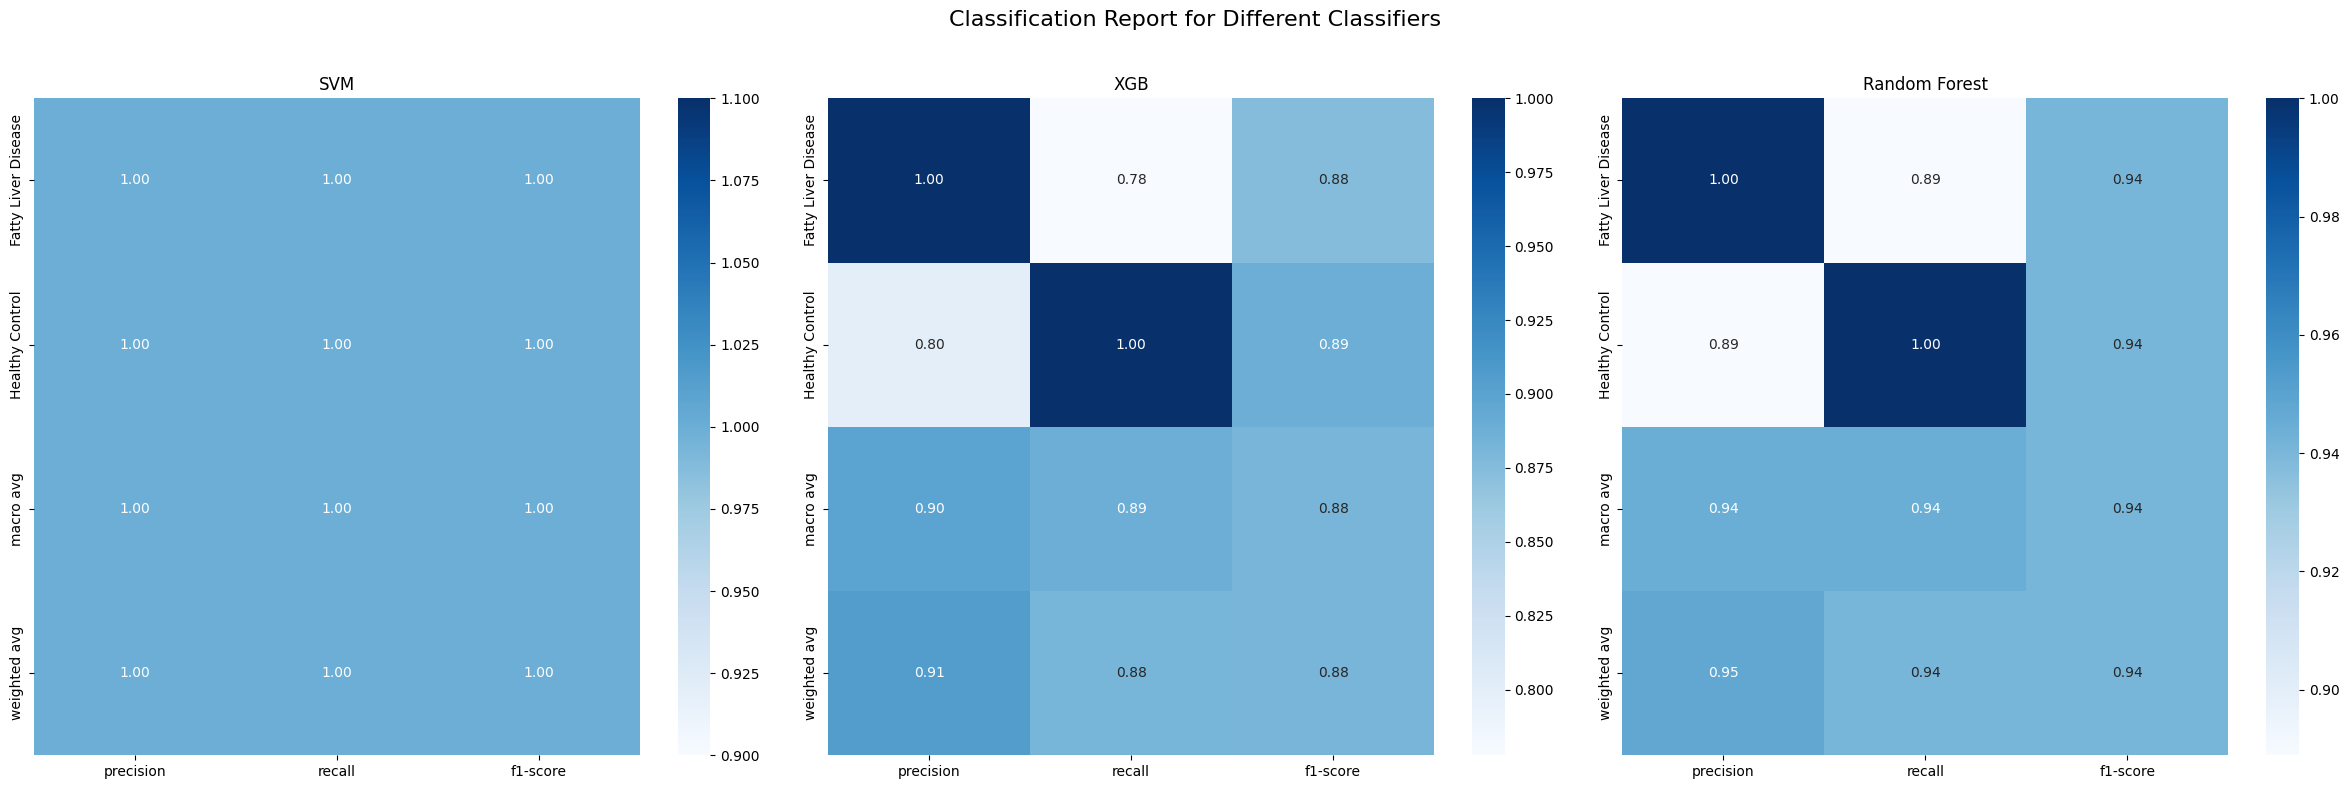

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
svm_classfication_report = svm_classfication_report.drop(columns="support", errors="ignore")
xgb_classification_report = xgb_classification_report.drop(columns="support", errors="ignore")
random_forest_classification_report = random_forest_classification_report.drop(columns="support", errors="ignore")

matrices = [svm_classfication_report, xgb_classification_report, random_forest_classification_report]
titles = ['SVM', 'XGB', 'Random Forest']

for i, (matrix, title) in enumerate(zip(matrices, titles)):
    sns.heatmap(matrix, annot=True, fmt=".2f", ax=axes[i], cmap="Blues")
    axes[i].set_title(title)

fig.suptitle('Classification Report for Different Classifiers', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()